## Setup

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

from csi_vae.jobs import JobSettings, dataset
from csi_vae.jobs.job import make_dataloader, train_fusion, train_gaussians

plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "figure.dpi": 300,
})

settings = JobSettings()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ACTIVITIES = [
    "Walk",
    "Run",
    "Jump",
    "Sit",
    "Empty",
    "Stand",
    "Waving",
    "Clap",
    "Lay down",
    "Wipe",
    "Squat",
    "Stretch",
]

## Train Models

In [2]:
full_train_ds, full_val_ds, full_test_ds = dataset.load(
    dataset_path=Path("../") / settings.dataset_path,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)

gaussians = train_gaussians(settings, full_train_ds, full_val_ds)
fusion = train_fusion(settings, full_train_ds, full_val_ds, gaussians)

## t-SNE

In [3]:
full_ds = torch.utils.data.ConcatDataset([full_train_ds, full_val_ds, full_test_ds])
full_dl = make_dataloader(full_ds, settings.batch_size, shuffle=False, seed=settings.seed)

all_latents, all_labels = [], []

for antenna_idx, gaussian in enumerate(gaussians):
    antenna_latents, antenna_labels = [], []

    gaussian.eval().to(DEVICE)
    for x, y in full_dl:
        with torch.no_grad():
            x_antenna = x[:, antenna_idx].to(DEVICE, dtype=torch.float32)
            mu, logvar = gaussian.encode(x_antenna)

            antenna_latents.append(torch.cat([mu, logvar], dim=1).cpu().numpy())
            antenna_labels.append(y.numpy())

    all_latents.append(np.concatenate(antenna_latents))
    all_labels.append(np.concatenate(antenna_labels))

Antenna 1


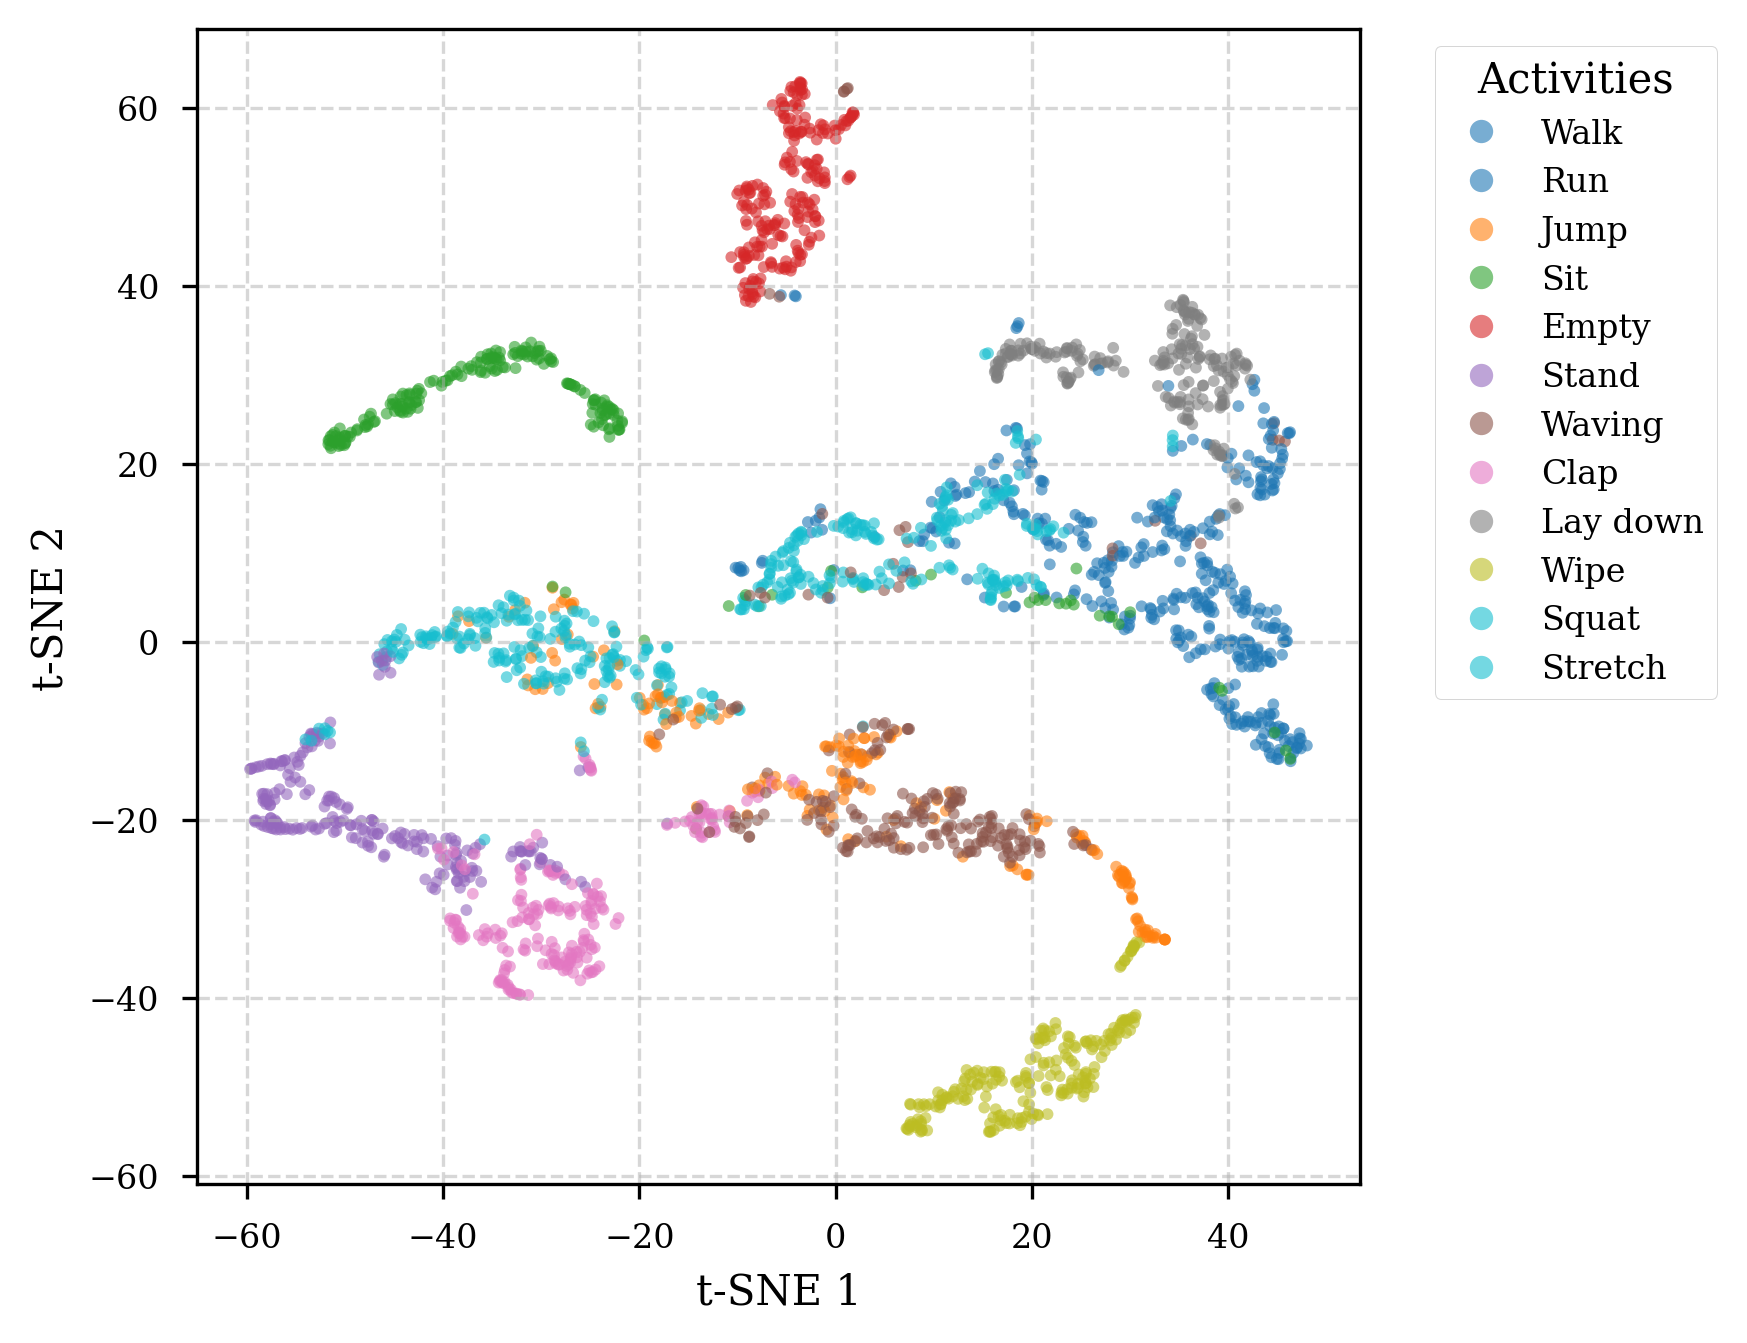

Antenna 2


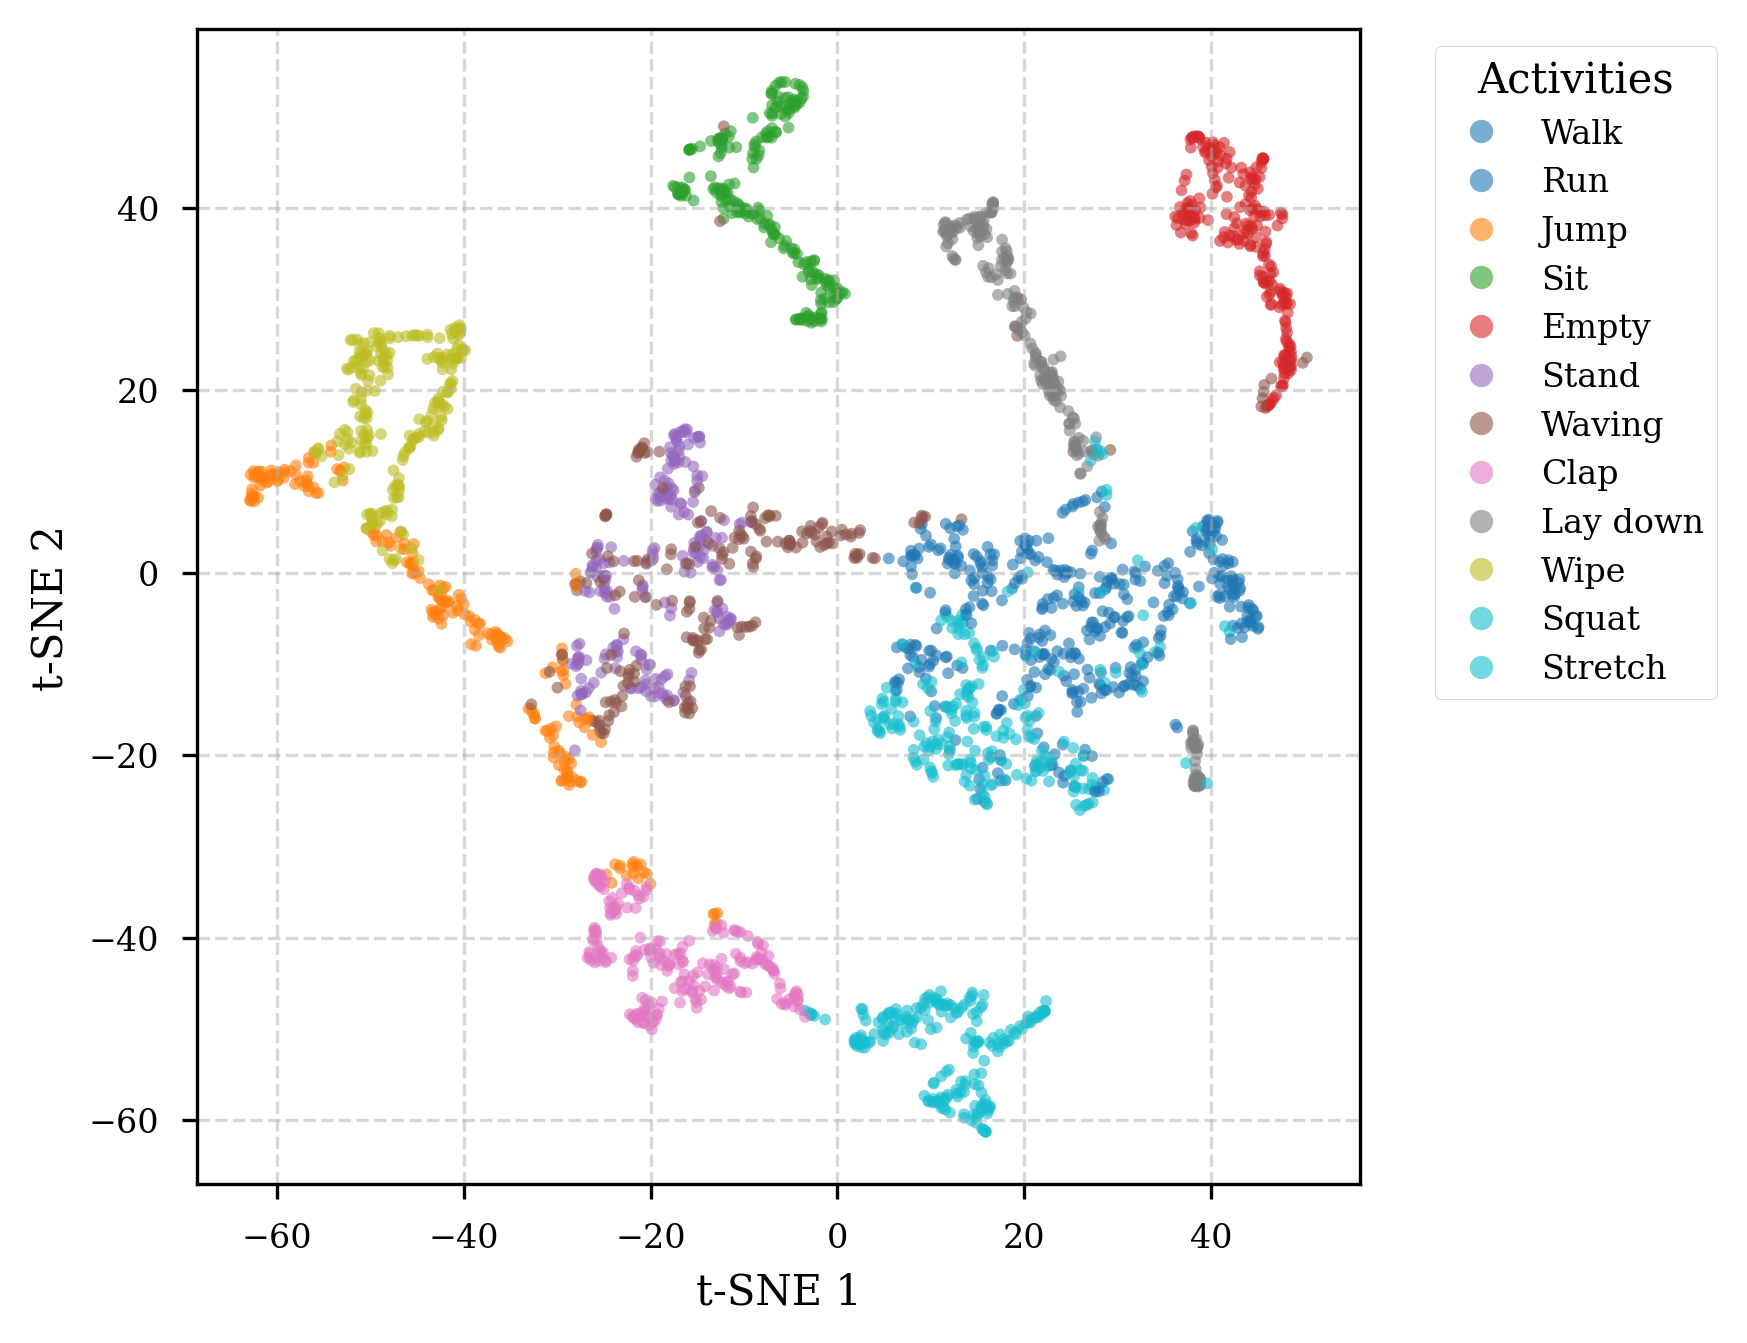

Antenna 3


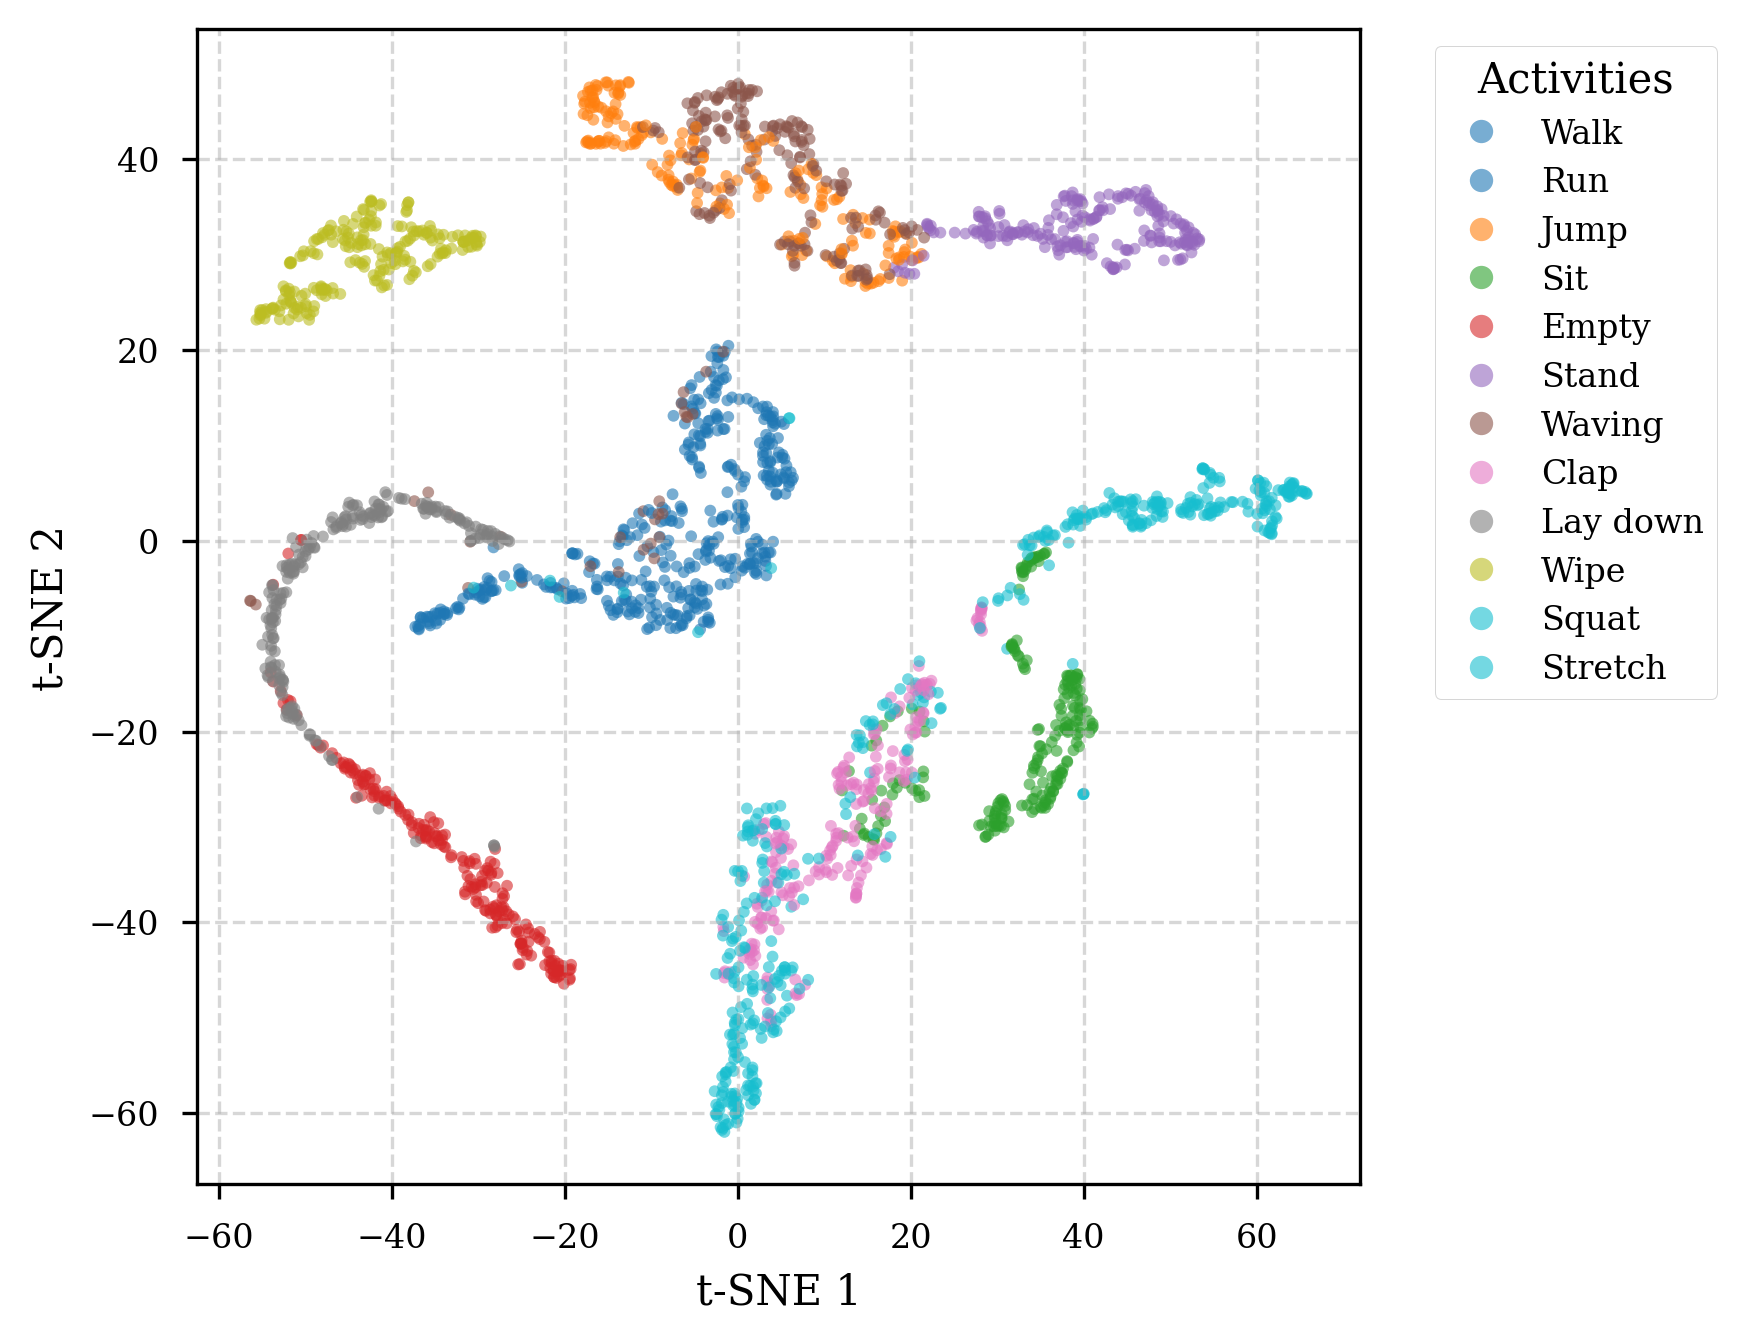

Antenna 4


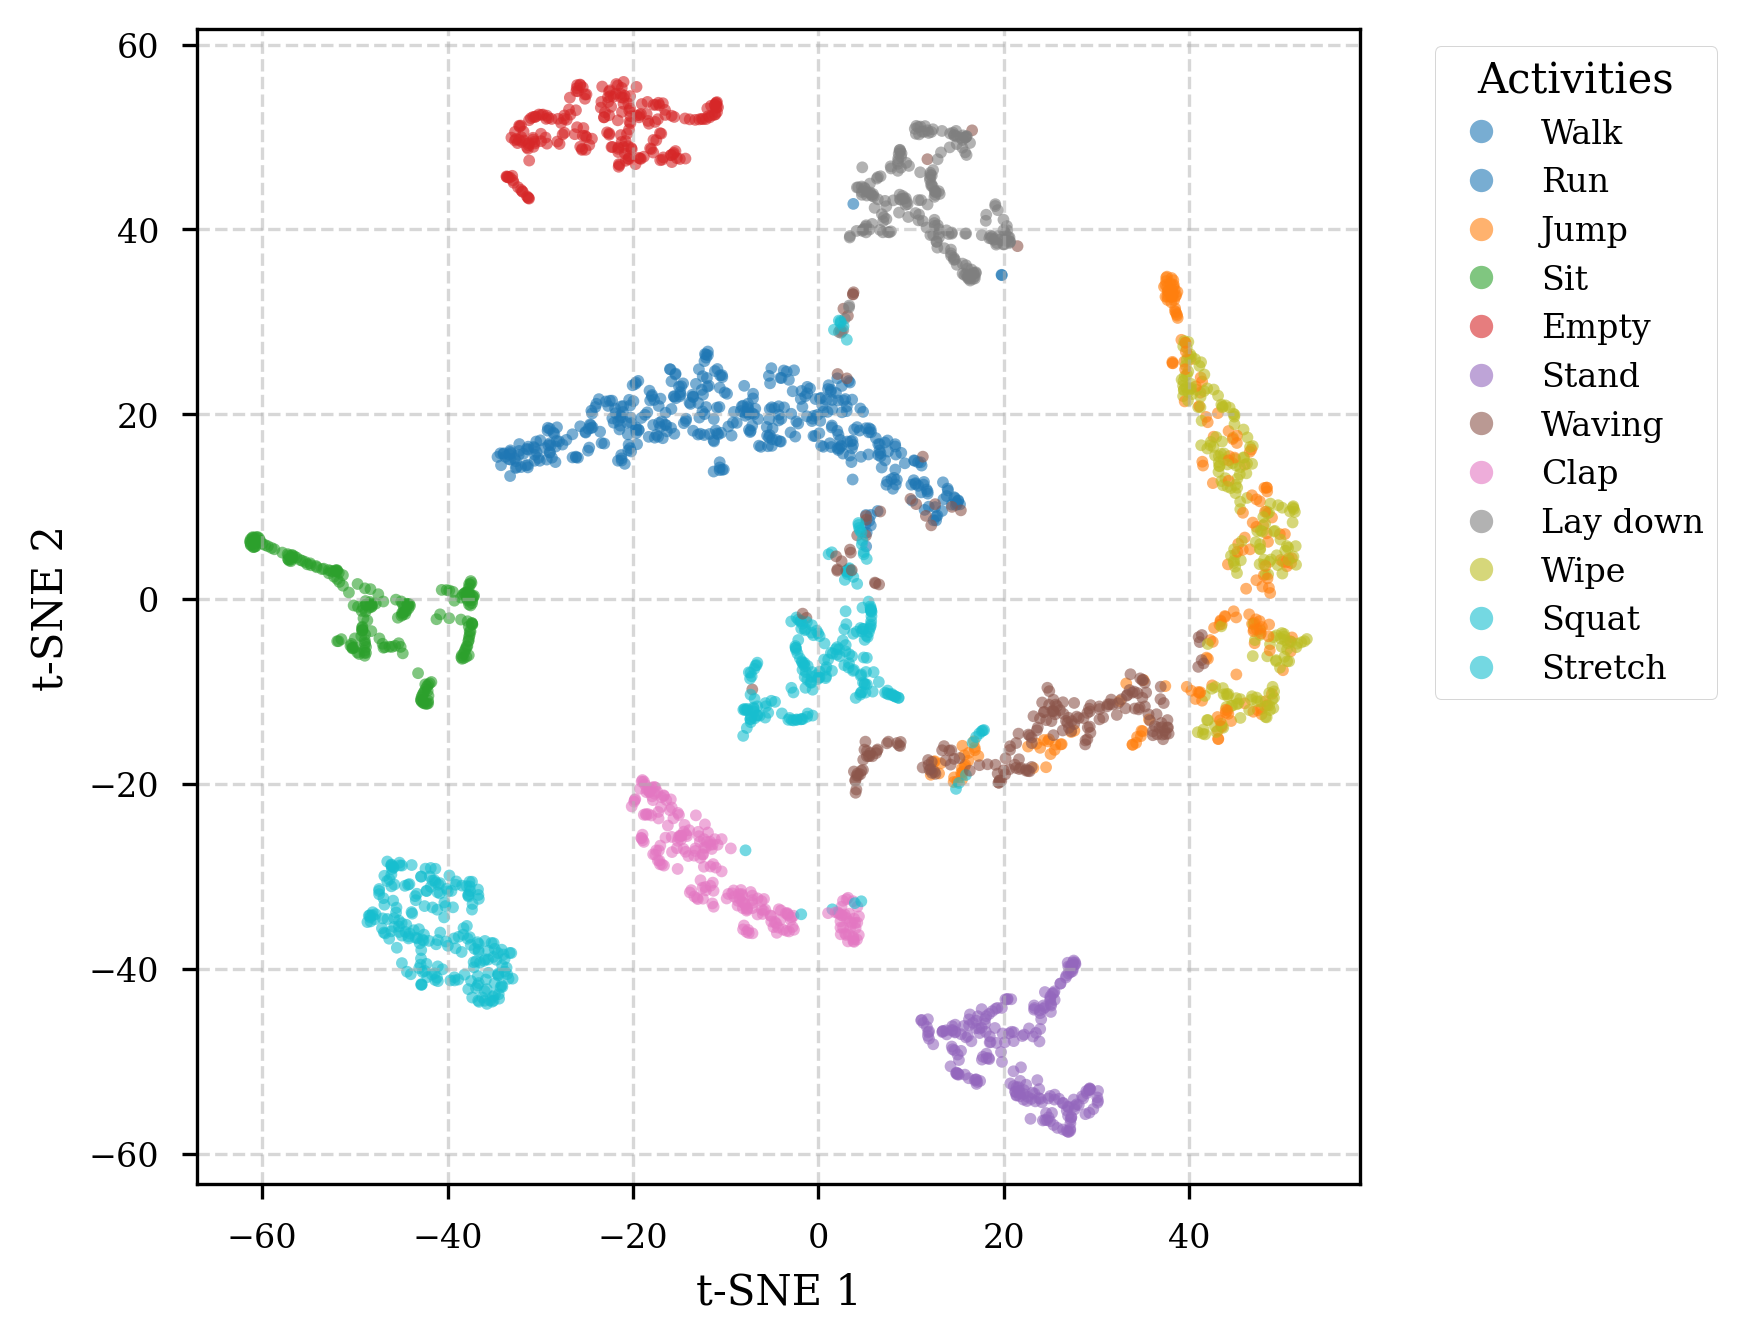

In [38]:
for antenna_idx, (latents, labels) in enumerate(zip(all_latents, all_labels, strict=True)):
    tsne = TSNE(
        n_components=2,
        random_state=settings.seed,
        perplexity=30,
    ).fit_transform(latents)

    print(f"Antenna {antenna_idx + 1}")

    plt.figure(figsize=(5, 5))
    scatter = plt.scatter(
        tsne[:, 0],
        tsne[:, 1],
        c=labels,
        cmap="tab10",
        label=labels,
        alpha=0.6,
        edgecolor="w",
        s=8,
        linewidths=0,
    )
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ACTIVITIES, title="Activities", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

## Confusion Matrix

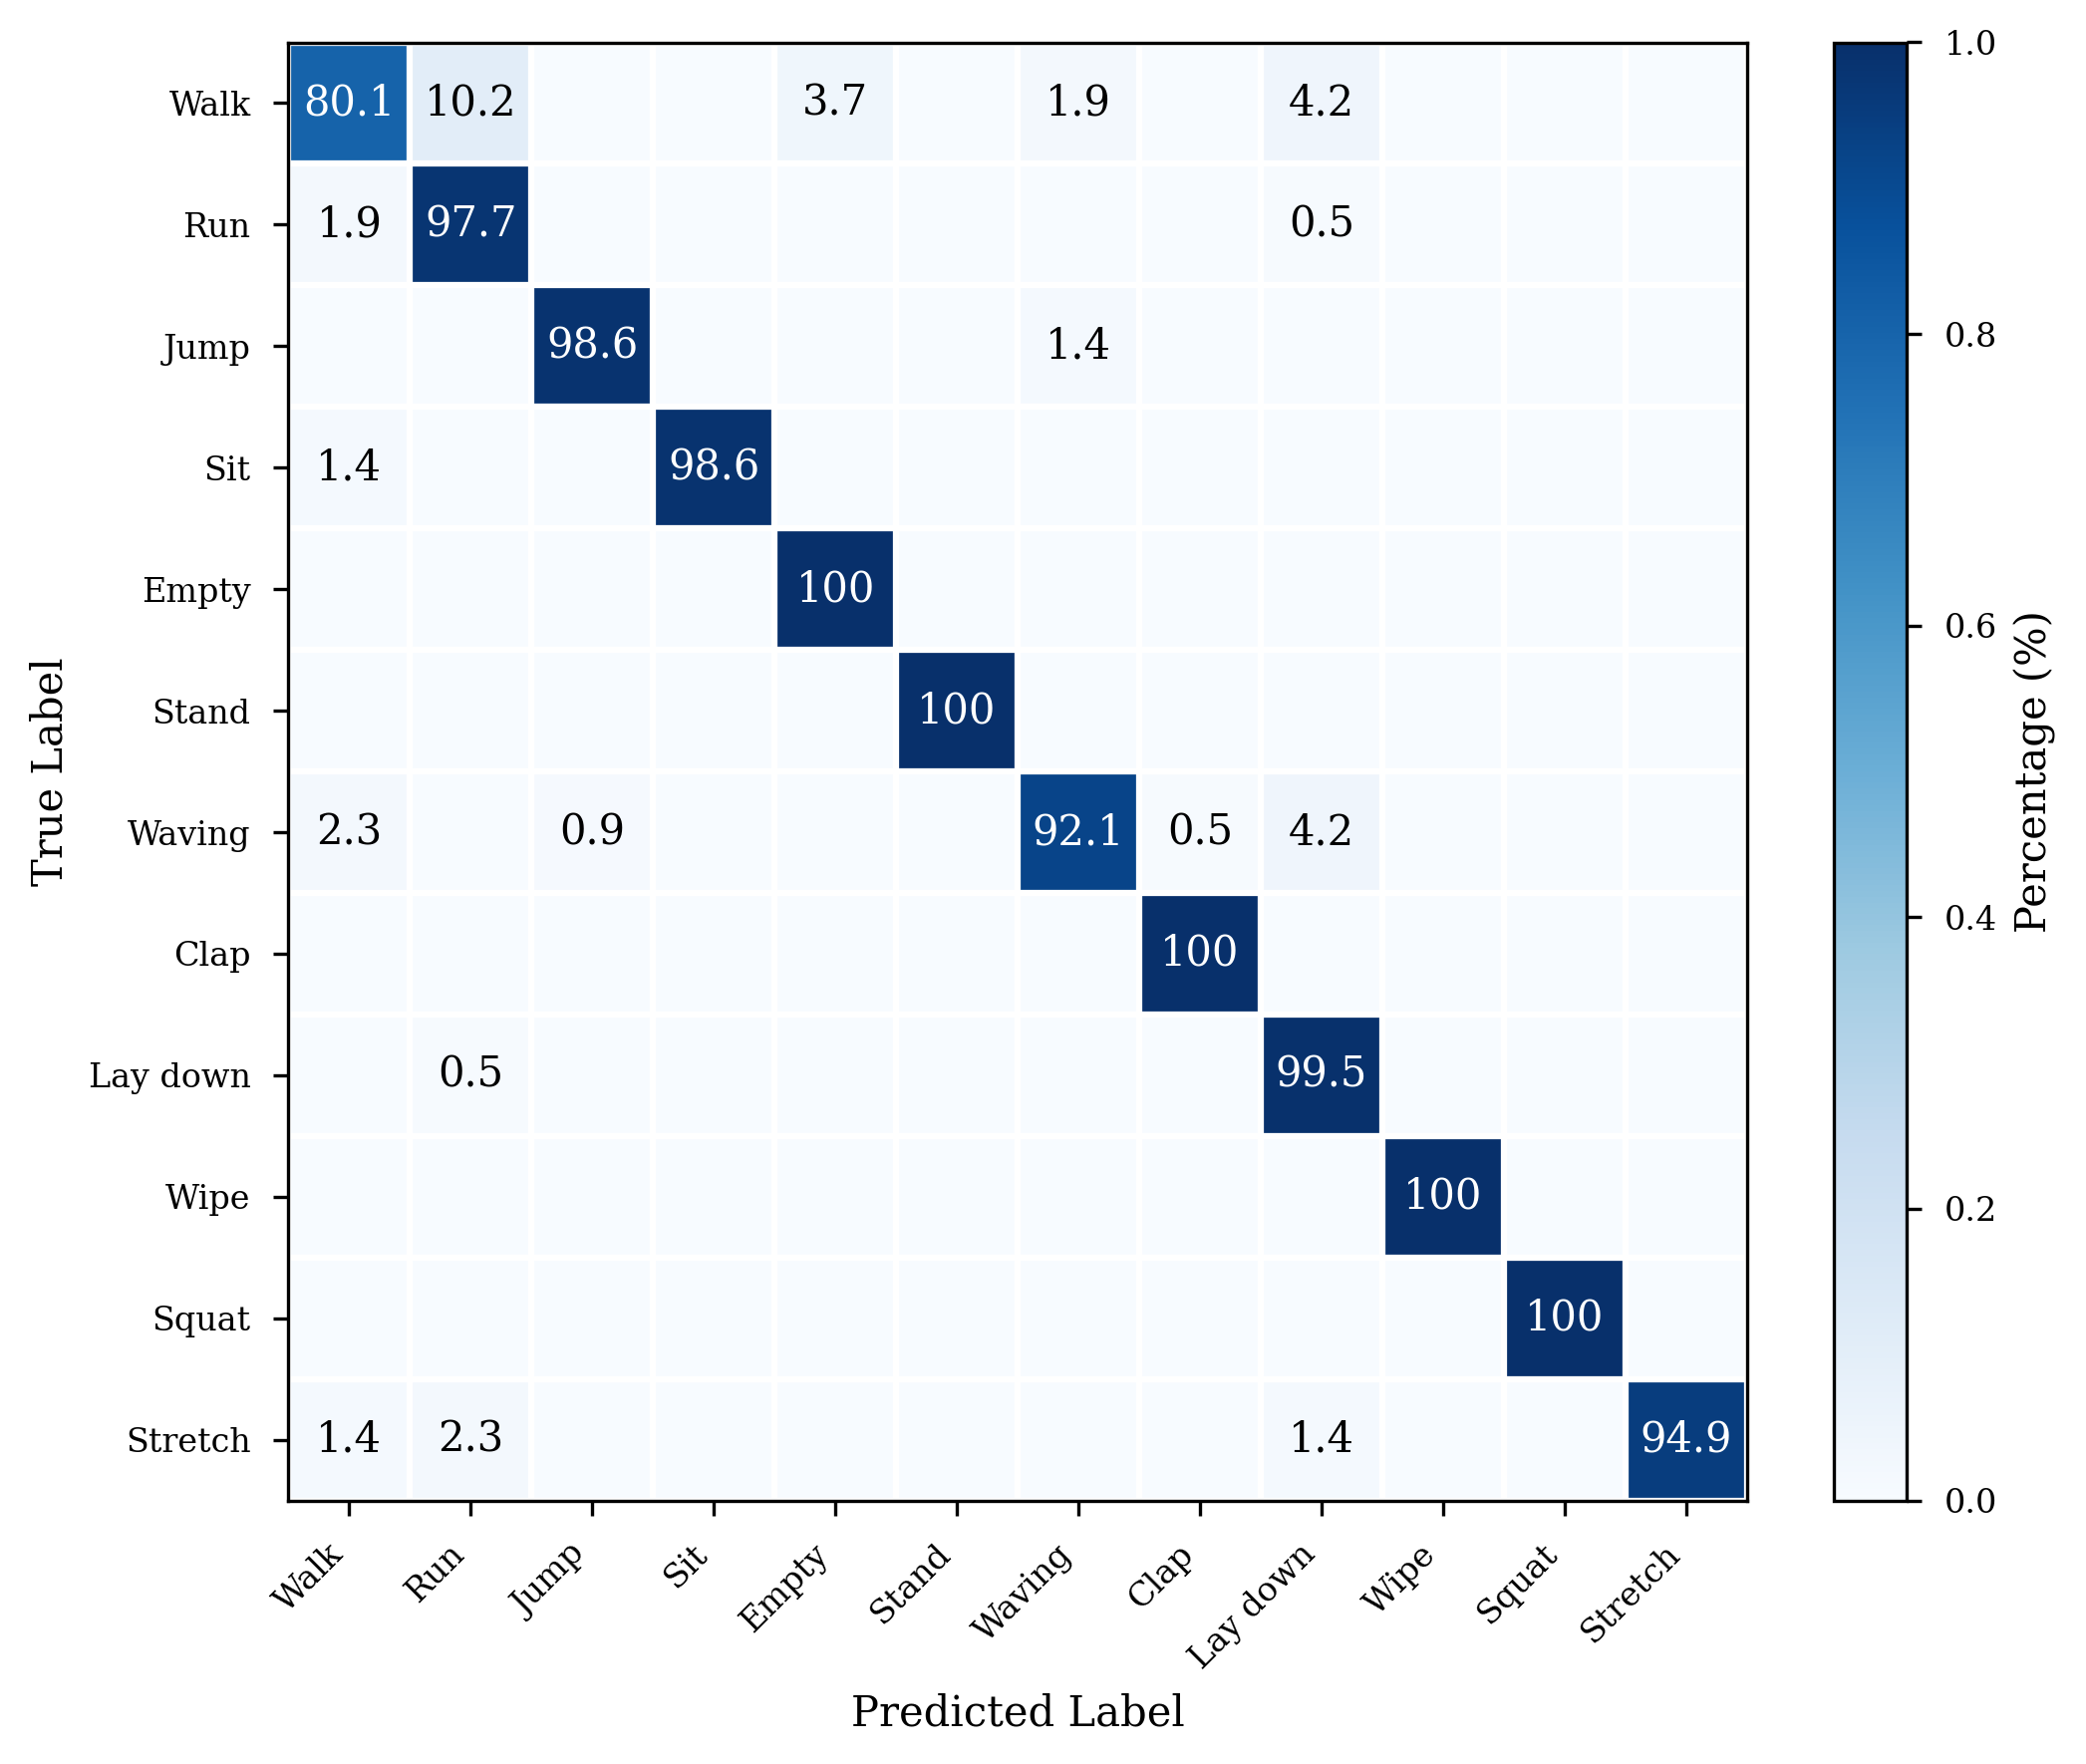

In [41]:
y_preds, y_trues = [], []
for x, y in full_dl:
    with torch.no_grad():
        y_pred = fusion(x.to(DEVICE, dtype=torch.float32))
        y_preds.append(y_pred.cpu().numpy())
        y_trues.append(y.numpy())

cm = confusion_matrix(
    np.concatenate(y_trues),
    np.concatenate(y_preds).argmax(axis=1),
)

plt.figure(figsize=(8, 6))
# Normalize by row (True Labels) to see percentages
matrix_perc = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)

im = plt.imshow(matrix_perc, cmap="Blues")

thresh = matrix_perc.max() / 2
for i in range(len(ACTIVITIES)):
    for j in range(len(ACTIVITIES)):
        if cm[i, j] == 0:
            continue  # Skip zero counts for better readability

        color = "white" if matrix_perc[i, j] > thresh else "black"
        text = f"{matrix_perc[i, j] * 100:.1f}".rstrip("0").rstrip(".")
        plt.text(j, i, text, ha="center", va="center", color=color)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right", ticks=np.arange(len(ACTIVITIES)), labels=ACTIVITIES)
plt.yticks(rotation=0, ticks=np.arange(len(ACTIVITIES)), labels=ACTIVITIES)

ax = plt.gca()
ax.set_xticks(np.arange(-0.5, len(ACTIVITIES)), minor=True)
ax.set_yticks(np.arange(-0.5, len(ACTIVITIES)), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.colorbar(im, fraction=0.046, pad=0.04, label="Percentage (%)")
plt.tight_layout()
plt.show()
plt.close()